<a href="https://colab.research.google.com/github/IronZiiz/Machine-Learning_Classification/blob/main/Project_metrics_validation_models__Cipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project
A car loan company is going through a challenging situation, with high demand for a limited fleet of vehicles and a high number of defaulters, causing significant losses for the company.

We were hired to improve the identification of defaulters. Currently, client analysis is done manually, one by one, which is very time-consuming and still results in a very inaccurate detection of defaulters.

Our task is to use the data provided by the company to classify clients as either compliant (paying) or defaulters.

### Import data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Alura/Classificação/Classificação: validação de modelos e métricas de avaliação/emp_automovel.csv')

## Exploratory data
Pre cleaned data
var target: inadimplente

In [ ]:
data.head(5)

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


### Vars exp and target

In [ ]:
x = data.drop('inadimplente', axis=1)
y = data['inadimplente']

## Classify Algorithm (Descision Tree)

### Study case : Overffiting model



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier()
model.fit(x, y)
model.score(x, y) # accuracy

1.0

In [ ]:
print(f"accuracy: {model.score(x, y)}")

accuracy: 1.0


### Study case : No Overffiting model

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# split data

x, x_test, y, y_test= train_test_split(x, y, test_size=0.15, stratify = y,random_state=5)
x_train, x_validation, y_train, y_validation = train_test_split(x, y, stratify = y,random_state=5)


In [ ]:
model_no_overfitting = DecisionTreeClassifier()
model_no_overfitting.fit(x_train, y_train)

print(f"Accuracy (train): {model_no_overfitting.score(x_train, y_train)}")
print(f"Accuracy (val): {model_no_overfitting.score(x_validation, y_validation)}")

Accuracy (train): 1.0
Accuracy (val): 0.8495775629300584


In [ ]:
model_no_overfitting = DecisionTreeClassifier(max_depth = 10)
model_no_overfitting.fit(x_train, y_train)

print(f"Accuracy (train): {model_no_overfitting.score(x_train, y_train)}")
print(f"Accuracy (val): {model_no_overfitting.score(x_validation, y_validation)}")

Accuracy (train): 0.9206445993031359
Accuracy (val): 0.9055831373573731


## Validation

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_predict = model_no_overfitting.predict(x_validation)
matrix_confusion = confusion_matrix(y_validation, y_predict)
print(matrix_confusion)

[[10353   126]
 [  958    44]]


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


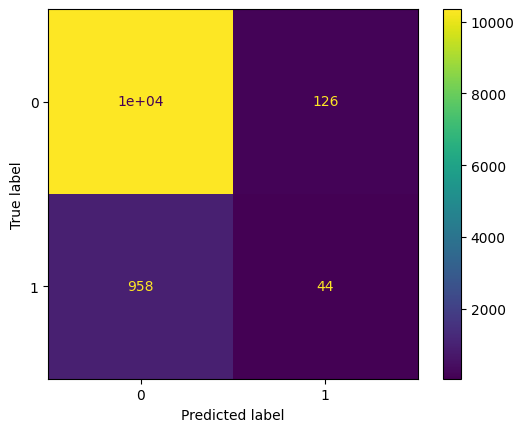

In [ ]:
viz = ConfusionMatrixDisplay(confusion_matrix=matrix_confusion)
viz.plot();

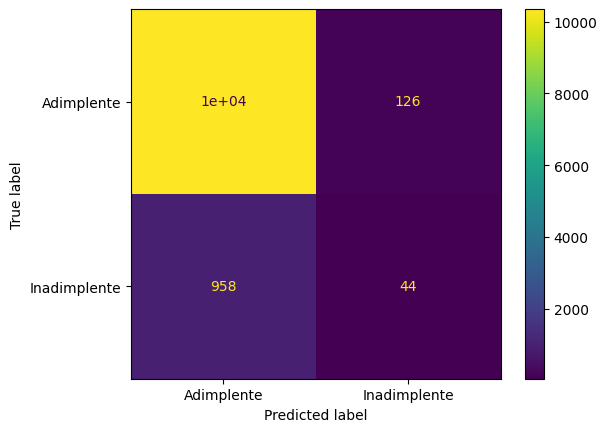

In [ ]:
viz = ConfusionMatrixDisplay(confusion_matrix=matrix_confusion, display_labels=['Adimplente', 'Inadimplente'])
viz.plot();

##

## Classify Algorithm (Random Forest )

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_random_forest = RandomForestClassifier(max_depth = 10)
model_random_forest.fit(x_train, y_train)
print(f'Acurácia de treino: {model_random_forest.score(x_train, y_train)}')
print(f'Acurácia de validação: {model_random_forest.score(x_validation, y_validation)}')

Acurácia de treino: 0.9153600464576074
Acurácia de validação: 0.9130737740614929


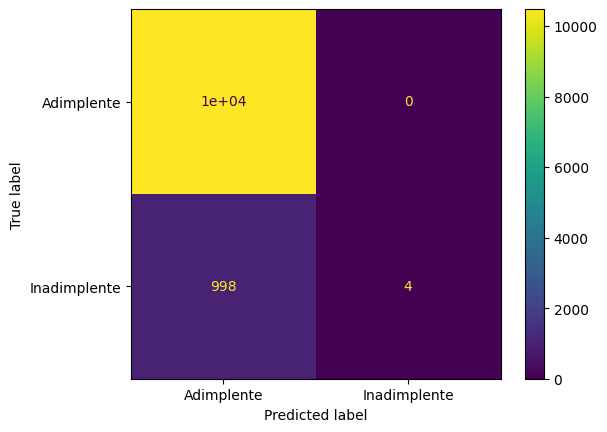

In [ ]:
y_predict_random_forest = model_random_forest.predict(x_validation)
matriz_confusao = confusion_matrix(y_validation, y_predict_random_forest)
visualizacao = ConfusionMatrixDisplay(confusion_matrix= matriz_confusao,
                                      display_labels = ['Adimplente', 'Inadimplente'])
visualizacao.plot();

## Accuracy, precision and Recall
0 - adimplência

1 - inadimplência


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
print(f'Acurácia: {accuracy_score(y_validation, y_predict)}')

Acurácia: 0.9055831373573731


In [ ]:
# true positives analysis
print(f'Precisão: {precision_score(y_validation, y_predict)}')


Precisão: 0.25882352941176473


In [ ]:
# false positives analysis
# more relevant because its refers to lost clients for inadimplence
print(f'Recall: {recall_score(y_validation, y_predict)}')

Recall: 0.043912175648702596


In [ ]:
from sklearn.metrics import f1_score

In [ ]:
print(f'F1 Score: {f1_score(y_validation, y_predict)}')

F1 Score: 0.07508532423208192


## ROC curve

In [ ]:
from sklearn.metrics import RocCurveDisplay


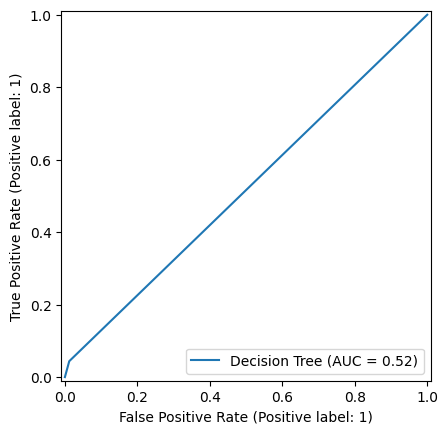

In [ ]:
RocCurveDisplay.from_predictions(y_validation, y_predict, name = 'Decision Tree');

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
print(f'ROC AUC: {roc_auc_score(y_validation, y_predict)}')

ROC AUC: 0.5159440637762551


## Precision Recall curve

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

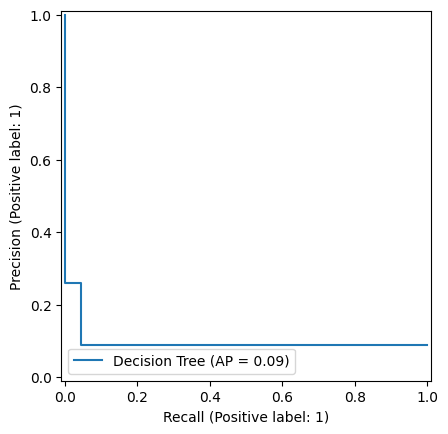

In [ ]:
PrecisionRecallDisplay.from_predictions(y_validation, y_predict, name = 'Decision Tree');

In [ ]:
from sklearn.metrics import average_precision_score

In [ ]:
print(f'Average Precision: {average_precision_score(y_validation, y_predict)}')


Average Precision: 0.09480771315237001


## Metrics Report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_validation, y_predict))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.26      0.04      0.08      1002

    accuracy                           0.91     11481
   macro avg       0.59      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



## Cross validation using KFold

In [ ]:
from sklearn.model_selection import cross_validate, KFold

### Accuracy metric

In [ ]:
model_dt_kfold = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_accuracy_target = cross_validate(model_dt_kfold, x, y, cv = kf)

In [ ]:
cv_results_accuracy_target['test_score']

array([0.91377246, 0.90766551, 0.90744774, 0.91365418, 0.89917247])

In [ ]:
mean = cv_results_accuracy_target['test_score'].mean()
std = cv_results_accuracy_target['test_score'].std()

print(f'Mean: {mean}')
print(f'Std: {std}')
print(f'Confidence Interval: {mean - 2 * std} , {min(mean + 2 *std,1)}')

Mean: 0.9083424701120407
Std: 0.0053487694759673235
Confidence Interval: 0.8976449311601061 , 0.9190400090639753


## recall metric

In [ ]:
def  conf_interval(results):
  mean = results['test_score'].mean()
  std = results['test_score'].std()

  print(f'Mean: {mean}')
  print(f'Std: {std}')
  print(f'Confidence Interval: {mean - 2 * std} , {min(mean + 2 *std,1)}')

In [ ]:
model_dt_kfold = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_recall_target = cross_validate(model_dt_kfold, x, y, cv = kf, scoring = 'recall')
cv_results_recall_target

{'fit_time': array([0.40054774, 0.38421202, 0.39943933, 0.43364477, 0.40902543]),
 'score_time': array([0.00919604, 0.00853539, 0.01325369, 0.01180792, 0.00897574]),
 'test_score': array([0.02906209, 0.02227723, 0.01845018, 0.01697128, 0.02427746])}

In [ ]:
conf_interval(cv_results_recall_target)

Mean: 0.02220764708632917
Std: 0.0043083726409576814
Confidence Interval: 0.013590901804413807 , 0.03082439236824453


In [ ]:
cv_results_precision_target = cross_validate(model_dt_kfold, x, y, cv = kf, scoring = 'precision')
cv_results_f1_scor_target = cross_validate(model_dt_kfold, x, y, cv = kf, scoring = 'f1')

### Evaluate all intervals for all metrics

In [ ]:
def all_conf_interval_metricas(accuracy_score, precision_score, recall_score, f1_score):
  list_names_metrics = ['accuracy_score', 'precision_score', 'recall_score', 'f1_score']
  list_metrics = [accuracy_score, precision_score, recall_score, f1_score]

  range = [0,1,2,3]
  for metric in range:
    mean = list_metrics[metric]['test_score'].mean()
    std = list_metrics[metric]['test_score'].std()
    print(f'{list_names_metrics[metric]}: Confidence Interval: {mean - 2 * std} , {min(mean + 2 *std,1)}')


In [ ]:
all_conf_interval_metricas(cv_results_accuracy_target, cv_results_precision_target, cv_results_recall_target, cv_results_f1_scor_target)

accuracy_score: Confidence Interval: 0.8976449311601061 , 0.9190400090639753
precision_score: Confidence Interval: 0.20099467441285992 , 0.27243982498481445
recall_score: Confidence Interval: 0.013590901804413807 , 0.03082439236824453
f1_score: Confidence Interval: 0.027224755040976146 , 0.052018126652494084


## Stratify Data

In [ ]:
data['inadimplente'].value_counts(normalize = True)

,proportion
inadimplente,
0,0.912707
1,0.087293


In [ ]:
from sklearn.model_selection import StratifiedKFold


In [ ]:
model_stratified_kfold = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_stratified_kfold = cross_validate(model_stratified_kfold, x, y, cv = skf, scoring = 'recall')

In [ ]:
conf_interval(cv_results_stratified_kfold)

Mean: 0.028185777752871254
Std: 0.0026783704748463647
Confidence Interval: 0.022829036803178524 , 0.033542518702563986


## Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversampl = SMOTE(random_state = 5)
x_over, y_over = oversampl.fit_resample(x, y)

In [ ]:
y_over.value_counts(normalize = True)

,proportion
inadimplente,
0,0.5
1,0.5


In [ ]:
model_oversampled = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_oversampled = cross_validate(model_oversampled, x_over, y_over, cv = skf, scoring = 'recall')

In [ ]:
conf_interval(cv_results_oversampled)

Mean: 0.7246610060873271
Std: 0.01010799959845929
Confidence Interval: 0.7044450068904085 , 0.7448770052842457


## Oversampling and Undersampling with SMOTEEN Algorithm

In [ ]:
from imblearn.combine import SMOTEENN

In [ ]:
sme = SMOTEENN (random_state = 5)
x_sme, y_sme = sme.fit_resample(x, y)

In [ ]:
y_sme.value_counts(normalize = True)

,proportion
inadimplente,
1,0.525519
0,0.474481


In [ ]:
model_oversampled_sme = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_oversampled_sme= cross_validate(model_oversampled_sme, x_sme, y_sme, cv = skf, scoring = 'recall')

In [ ]:
conf_interval(cv_results_oversampled_sme)

Mean: 0.7537308753626476
Std: 0.012555624932379293
Confidence Interval: 0.7286196254978891 , 0.7788421252274061


## Pipeline to validation



In [ ]:
from imblearn.pipeline import Pipeline as imbpip

### Oversampling

In [ ]:
model_pipeline = DecisionTreeClassifier(max_depth=10)
pipeline = imbpip(steps = [('oversample', SMOTE(random_state = 5)), ('tree', model_pipeline)])

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_pipeline= cross_validate(pipeline, x, y, cv = skf, scoring = 'recall')

In [ ]:
conf_interval(cv_results_pipeline)

Mean: 0.2484378940289725
Std: 0.0146478859021861
Confidence Interval: 0.2191421222246003 , 0.2777336658333447


### Undersampling

In [ ]:
from imblearn.under_sampling import NearMiss

In [ ]:
model_pipeline = DecisionTreeClassifier(max_depth=10)
pipeline = imbpip(steps = [('undersample', NearMiss(version = 3)), ('tree', model_pipeline)])

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_pipeline= cross_validate(pipeline, x, y, cv = skf, scoring = 'recall')

In [ ]:
conf_interval(cv_results_pipeline)

Mean: 0.6582607152530658
Std: 0.017787978311429222
Confidence Interval: 0.6226847586302074 , 0.6938366718759242


## Final model

In [ ]:
undersample = NearMiss(version = 3)
x_undersample, y_undersample = undersample.fit_resample(x, y)


              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



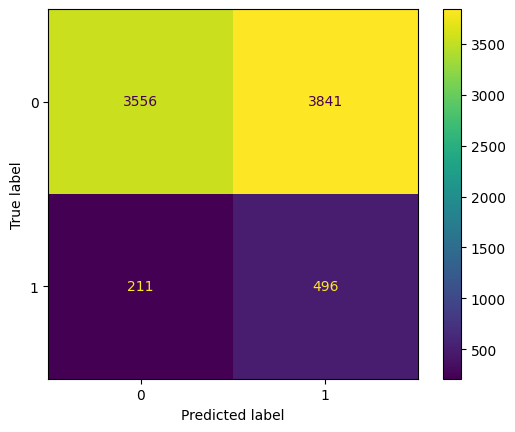

In [ ]:
model_final = DecisionTreeClassifier(max_depth = 10)
model_final.fit(x_undersample, y_undersample)

y_predict = model_final.predict(x_test)

print(classification_report(y_test, y_predict))
ConfusionMatrixDisplay.from_predictions(y_test, y_predict);